# 0 · Comparación de productos: Atlas Urbano 2020 vs. LCLU Uruguay 2021

Este notebook introduce el ejercicio del taller mediante una comparación entre dos productos que describen el mismo territorio con **leyendas, resoluciones y metodologías diferentes**:

- **Atlas Urbano LAC 2020 (AU)**: producto raster.
- **LCLU Uruguay 2021**: producto originalmente vectorial, previamente rasterizado para `CLASE` y `SUBCLASE`.

La comparación se realiza **directamente sobre el área espacial común** entre ambos productos. LCLU Uruguay no se utiliza como verdad terreno y el resultado no se interpreta como una matriz de confusión. El objetivo es estudiar **correspondencias y diferencias temáticas** entre dos sistemas de clasificación.

> **Importante:** 2021 corresponde al año disponible más cercano al Atlas Urbano 2020. Una diferencia espacial entre ambos productos no debe interpretarse automáticamente como un cambio real del territorio.

## Flujo de trabajo

La primera figura resume la secuencia del notebook. La idea es avanzar desde la comprensión de ambos productos hasta una comparación espacial de sus clases, y cerrar con un análisis local por departamento y municipio.

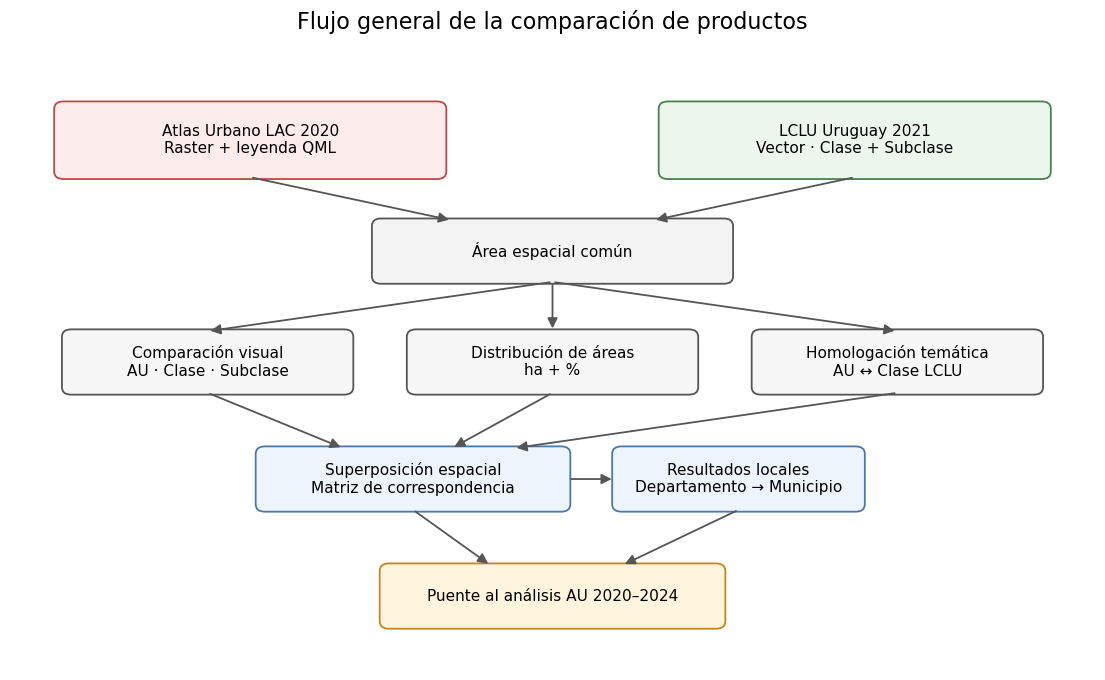

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis("off")


def caja(x, y, w, h, texto, fc="#f7f7f7", ec="#555555", fontsize=11):
    p = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.03,rounding_size=0.12",
        linewidth=1.3, edgecolor=ec, facecolor=fc
    )
    ax.add_patch(p)
    ax.text(x+w/2, y+h/2, texto, ha="center", va="center", fontsize=fontsize)
    return p


def flecha(x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch(
        (x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=15,
        linewidth=1.3, color="#555555"
    ))

caja(0.6, 8.0, 5.0, 1.2, "Atlas Urbano LAC 2020\nRaster + leyenda QML", "#fdecec", "#b94a48")
caja(8.4, 8.0, 5.0, 1.2, "LCLU Uruguay 2021\nVector · Clase + Subclase", "#edf6ed", "#4d7f4d")
caja(4.7, 6.3, 4.6, 1.0, "Área espacial común", "#f3f3f3")
caja(0.7, 4.5, 3.7, 1.0, "Comparación visual\nAU · Clase · Subclase", "#f7f7f7")
caja(5.15, 4.5, 3.7, 1.0, "Distribución de áreas\nha + %", "#f7f7f7")
caja(9.6, 4.5, 3.7, 1.0, "Homologación temática\nAU ↔ Clase LCLU", "#f7f7f7")
caja(3.2, 2.6, 4.0, 1.0, "Superposición espacial\nMatriz de correspondencia", "#eef4fb", "#4c78a8")
caja(7.8, 2.6, 3.2, 1.0, "Resultados locales\nDepartamento → Municipio", "#eef4fb", "#4c78a8")
caja(4.8, 0.7, 4.4, 1.0, "Puente al análisis AU 2020–2024", "#fff4dd", "#c4871b")

flecha(3.1, 8.0, 5.7, 7.3)
flecha(10.9, 8.0, 8.3, 7.3)
flecha(7.0, 6.3, 2.55, 5.5)
flecha(7.0, 6.3, 7.0, 5.5)
flecha(7.0, 6.3, 11.45, 5.5)
flecha(2.55, 4.5, 4.3, 3.6)
flecha(7.0, 4.5, 5.7, 3.6)
flecha(11.45, 4.5, 6.5, 3.6)
flecha(7.2, 3.1, 7.8, 3.1)
flecha(5.2, 2.6, 6.2, 1.7)
flecha(9.4, 2.6, 7.9, 1.7)

ax.set_title("Flujo general de la comparación de productos", fontsize=16, pad=18)
plt.show()

## 1. Preparación del entorno

El notebook está diseñado para ejecutarse directamente desde la estructura del repositorio del taller. **No utiliza rutas absolutas**.

Los raster del LCLU Uruguay ya fueron preparados previamente sobre **la misma grilla del Atlas Urbano 2020**. Esto evita ejecutar `dissolve`, intersecciones vectoriales masivas o rasterizaciones durante el taller.

Estructura mínima esperada:

```text
TALLER_UY/
├── data/
│   ├── CRC_AU_ES.qml
│   ├── homologacion_LCCS_UY/
│   │   ├── LCLU_UY_CLASE.tif
│   │   └── LCLU_UY_SUBCLASE.tif
│   ├── rasters_AU/
│   │   ├── 2020/
│   │   │   └── UA_UY_2020.tif
│   │   └── 2024/
│   │       └── UA_UY_2024.tif
│   └── shapes_AU/
│       └── municipios_20250507.*
├── notebooks/
│   ├── 0_Comparacion_productos.ipynb
│   └── TALLER_UY_Atlas_Urbano_avanzado.ipynb
└── outputs/
```


In [2]:
from pathlib import Path
from collections import OrderedDict
import warnings
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb, to_hex

import rasterio
from rasterio.mask import mask
from rasterio.features import rasterize
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
from rasterio.windows import Window, transform as window_transform

from shapely.geometry import mapping
from shapely.ops import unary_union

import ipywidgets as widgets
from IPython.display import display, clear_output

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 100)

In [28]:
# ============================================================
# CONFIGURACIÓN PORTABLE DEL REPOSITORIO
# ============================================================

def encontrar_raiz_proyecto():
    actual = Path.cwd().resolve()

    for carpeta in [actual, *actual.parents]:
        if (carpeta / "data" / "rasters_AU").exists():
            return carpeta

    raise FileNotFoundError(
        "No fue posible localizar la raíz del proyecto. "
        "Ejecuta este notebook desde una carpeta contenida dentro del repositorio TALLER_UY."
    )


ROOT = encontrar_raiz_proyecto()

DATA_DIR = ROOT / "data"
SHAPES_DIR = DATA_DIR / "shapes_AU"
RASTERS_DIR = DATA_DIR / "rasters_AU"
HOMOLOGACION_DIR = RASTERS_DIR / "homologacion_LCCS_UY"

OUTPUT_DIR = ROOT / "outputs" / "output_AU" / "0_Comparacion_productos"

GUARDAR_SALIDAS = True

if GUARDAR_SALIDAS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RASTER_AU_2020 = RASTERS_DIR / "2020" / "AU_UY_2020.tif"

LCLU_CLASE = HOMOLOGACION_DIR / "LCLU_UY_CLASE.tif"
LCLU_SUBCLASE = HOMOLOGACION_DIR / "LCLU_UY_SUBCLASE.tif"

MUNICIPIOS = SHAPES_DIR / "municipios_20250507.shp"
QML_AU = DATA_DIR / "CRC_AU_ES.qml"

# CRS métrico usado internamente para el cálculo de superficies.
CRS_AREA = "EPSG:32721"

print("Raíz del proyecto:", ROOT)
print("AU 2020:", RASTER_AU_2020.relative_to(ROOT))
print("LCLU Clase:", LCLU_CLASE.relative_to(ROOT))
print("LCLU Subclase:", LCLU_SUBCLASE.relative_to(ROOT))
print("Municipios:", MUNICIPIOS.relative_to(ROOT) if MUNICIPIOS.exists() else "NO ENCONTRADO")
print("QML AU:", QML_AU.relative_to(ROOT))

Raíz del proyecto: C:\Users\fguti\OneDrive\Documentos\Taller-IDE-Uruguay
AU 2020: data\rasters_AU\2020\AU_UY_2020.tif
LCLU Clase: data\rasters_AU\homologacion_LCCS_UY\LCLU_UY_CLASE.tif
LCLU Subclase: data\rasters_AU\homologacion_LCCS_UY\LCLU_UY_SUBCLASE.tif
Municipios: data\shapes_AU\municipios_20250507.shp
QML AU: data\CRC_AU_ES.qml


In [6]:
# ============================================================
# VALIDACIÓN TEMPRANA DE INSUMOS
# ============================================================

requeridos = {
    "Atlas Urbano 2020": RASTER_AU_2020,
    "LCLU Uruguay · Clase": LCLU_CLASE,
    "LCLU Uruguay · Subclase": LCLU_SUBCLASE,
    "Simbología AU": QML_AU,
    "Municipios": MUNICIPIOS,
}

faltantes = []

for nombre, ruta in requeridos.items():
    if ruta.exists():
        print(f"✓ {nombre}: {ruta.relative_to(ROOT)}")
    else:
        print(f"✗ {nombre}: NO ENCONTRADO")
        faltantes.append(nombre)

if faltantes:
    raise FileNotFoundError(
        "Faltan insumos requeridos: " + ", ".join(faltantes)
    )

print("\n✓ Los insumos principales están disponibles.")

✓ Atlas Urbano 2020: data\rasters_AU\2020\AU_UY_2020.tif
✓ LCLU Uruguay · Clase: data\rasters_AU\homologacion_LCCS_UY\LCLU_UY_CLASE.tif
✓ LCLU Uruguay · Subclase: data\rasters_AU\homologacion_LCCS_UY\LCLU_UY_SUBCLASE.tif
✓ Simbología AU: data\CRC_AU_ES.qml
✓ Municipios: data\shapes_AU\municipios_20250507.shp

✓ Los insumos principales están disponibles.


## 2. Carga de LCLU Uruguay preprocesado

Para agilizar el taller se utilizan directamente dos raster categóricos preparados previamente:

- `LCLU_UY_CLASE.tif`
- `LCLU_UY_SUBCLASE.tif`

Ambos fueron rasterizados sobre **la misma grilla del Atlas Urbano 2020**. Por ello deben compartir dimensiones, CRS, transformación espacial y extensión.

Los códigos de `CLASE` y `SUBCLASE` se traducen a nombres mediante diccionarios incorporados directamente en el notebook.

> El valor `0` se reserva como `nodata` / ausencia de categoría LCLU.

In [7]:
def limpiar_etiqueta(valor):
    if pd.isna(valor):
        return valor
    s = str(valor)
    reemplazos = {
        "¤": "ñ",
        "¢": "ó",
        "µ": "Á",
        "�": "Á",
    }
    for a, b in reemplazos.items():
        s = s.replace(a, b)
    return s


def buscar_columna(df, candidatos, requerida=True):
    mapa = {str(c).strip().lower(): c for c in df.columns}
    for c in candidatos:
        if c.lower() in mapa:
            return mapa[c.lower()]
    if requerida:
        raise KeyError(f"No se encontró ninguna de estas columnas: {candidatos}")
    return None

In [8]:
# ============================================================
# LEYENDA LCLU INCORPORADA EN EL NOTEBOOK
# ============================================================

LOOKUP_CLASE = {
    1: "Aguas Artificiales",
    2: "Aguas Naturales",
    3: "Arbustos",
    4: "Area Desnuda",
    5: "Area Impermeable",
    6: "Area Natural Inundada",
    7: "Bosque Nativo",
    8: "Cantera, arenera, mina a cielo abierto",
    9: "Cultivos",
    10: "Frutales",
    11: "Pastizal",
    12: "Plantación Forestal",
}

LOOKUP_SUBCLASE = {
    1: "Arbusto",
    2: "Area Impermeable",
    3: "Area Impermeable Dispersa",
    4: "Arena",
    5: "Bañados/Humedales",
    6: "Bosque Nativo",
    7: "Bosque Nativo Disperso",
    8: "Cantera, Arenera, Mina a Cielo Abierto",
    9: "Cuerpo de Agua Artificial",
    10: "Cuerpo de Agua Natural",
    11: "Cultivo de Arroz",
    12: "Cultivo de invierno",
    13: "Cultivo de invierno y verano (Doble Cultivo)",
    14: "Cultivo de verano",
    15: "Cultivos pequeños",
    16: "Frutales",
    17: "Monte de abrigo y sombra",
    18: "Pastizal",
    19: "Pastizal Con Afloramiento Rocoso",
    20: "Pastizal Húmedo y/o Periodicamente Inundado",
    21: "Pastizal de Uso Agrícola",
    22: "Pastizal de uso agrícola",
    23: "Plantación Forestal nueva o cosechada",
    24: "Plantación Forestal Eucaliptus",
    25: "Plantación Forestal Mixta o Desconocida",
    26: "Plantación Forestal Pino",
    27: "Roca Consolidada",
    28: "Suelo Desnudo",
    29: "Suelo Desnudo de Uso Agrícola",
}

lookup_clase = pd.DataFrame(
    list(LOOKUP_CLASE.items()),
    columns=["ID_CLASE", "CLASE"],
)

lookup_subclase = pd.DataFrame(
    list(LOOKUP_SUBCLASE.items()),
    columns=["ID_SUBCLASE", "SUBCLASE"],
)

# ============================================================
# COMPROBACIÓN DE ALINEACIÓN DE LOS TRES RASTER
# ============================================================

# ============================================================
# COMPROBACIÓN DE ALINEACIÓN DE LOS TRES RASTER
# ============================================================

def transforms_equivalentes(t1, t2, atol=1e-9):
    """
    Compara dos transformaciones espaciales permitiendo
    pequeñas diferencias numéricas de punto flotante.
    """
    return np.allclose(
        np.array(t1)[:6],
        np.array(t2)[:6],
        rtol=0,
        atol=atol
    )


with rasterio.open(RASTER_AU_2020) as au, \
     rasterio.open(LCLU_CLASE) as lc, \
     rasterio.open(LCLU_SUBCLASE) as ls:

    comprobaciones = {
        "Misma dimensión AU / CLASE":
            (au.width, au.height) == (lc.width, lc.height),

        "Misma dimensión AU / SUBCLASE":
            (au.width, au.height) == (ls.width, ls.height),

        "Mismo CRS":
            au.crs == lc.crs == ls.crs,

        "Transform equivalente AU / CLASE":
            transforms_equivalentes(
                au.transform,
                lc.transform
            ),

        "Transform equivalente AU / SUBCLASE":
            transforms_equivalentes(
                au.transform,
                ls.transform
            ),
    }

    for nombre, ok in comprobaciones.items():
        print(
            f"{'✓' if ok else '✗'} "
            f"{nombre}: {ok}"
        )

    if not all(comprobaciones.values()):
        raise ValueError(
            "Los raster LCLU no están suficientemente "
            "alineados con el Atlas Urbano."
        )

✓ Misma dimensión AU / CLASE: True
✓ Misma dimensión AU / SUBCLASE: True
✓ Mismo CRS: True
✓ Transform equivalente AU / CLASE: True
✓ Transform equivalente AU / SUBCLASE: True


### Nota sobre el CRS y las superficies

Los raster de comparación permanecen en la misma grilla del Atlas Urbano para simplificar las superposiciones píxel a píxel.

Para calcular superficies en hectáreas, el notebook reproyecta **internamente** el recorte de trabajo a **EPSG:32721 (UTM 21S)** mediante vecino más cercano. Esto preserva las categorías y evita calcular áreas directamente en EPSG:4326 o EPSG:3857.

## 3. Leyenda del Atlas Urbano desde `CRC_AU_ES.qml`

Para evitar duplicar manualmente la leyenda, el notebook intenta leer códigos, etiquetas y colores directamente desde el QML utilizado en los demás ejercicios del taller.

In [9]:
def leer_leyenda_qml(qml_path):
    tree = ET.parse(qml_path)
    root = tree.getroot()
    filas = []

    # Caso habitual en raster categórico de QGIS
    for elem in root.iter():
        tag = elem.tag.split("}")[-1]
        if tag in {"paletteEntry", "item"}:
            attrs = elem.attrib
            if "value" in attrs and ("color" in attrs or "label" in attrs):
                try:
                    valor = int(float(attrs["value"]))
                except Exception:
                    continue
                filas.append({
                    "codigo": valor,
                    "clase_au": attrs.get("label", str(valor)),
                    "color": attrs.get("color", "#808080"),
                })

    if not filas:
        raise ValueError(
            "No fue posible extraer entradas de leyenda desde el QML. "
            "Revisar la estructura de CRC_AU_ES.qml."
        )

    df = pd.DataFrame(filas).drop_duplicates(subset="codigo").sort_values("codigo").reset_index(drop=True)
    df["clase_au"] = df["clase_au"].map(limpiar_etiqueta)
    return df

leyenda_au = leer_leyenda_qml(QML_AU)
leyenda_au

,codigo,clase_au,color
0,4368,4368 - Residencial,#fcdb72
1,4384,4384 - Comercial/Industrial,#cd6667
2,4400,4400 - Edificios,#9986f7
3,4624,4624 - Calles y ferrocarriles,#dfdfdf
4,4640,4640 - Aeropuertos,#676767
5,5136,5136 - Vegetación boscosa,#52a53d
6,5152,5152 - Agricultura,#f490dd
7,5168,5168 - Recreación,#ff5f5f
8,5184,5184 - Otros espacios abiertos,#8c5e4c
9,36880,36880 - Extracción de minerales,#fca55e


In [10]:
with rasterio.open(RASTER_AU_2020) as src:
    print("Atlas Urbano 2020")
    print("-----------------")
    print("CRS:", src.crs)
    print("Tamaño:", src.width, "x", src.height)
    print("Bandas:", src.count)
    print("Nodata:", src.nodata)
    print("Tipo de dato:", src.dtypes[0])
    print("Resolución:", src.res)
    print("Bounds:", src.bounds)

Atlas Urbano 2020
-----------------
CRS: EPSG:4326
Tamaño: 11695 x 4738
Bandas: 1
Nodata: 0.0
Tipo de dato: uint16
Resolución: (8.69324335185975e-05, 8.693243351625137e-05)
Bounds: BoundingBox(left=-56.431806822, bottom=-34.947347002, right=-55.415132012, top=-34.535461132)


## 4. Área espacial común

Como los tres raster comparten exactamente la misma grilla, el área de comparación se obtiene directamente a partir de los píxeles donde:

1. el Atlas Urbano contiene una clase válida; y
2. LCLU Uruguay contiene una `CLASE` distinta de `0`.

A partir de este punto, todas las estadísticas globales se restringen a esa superposición.

In [11]:
# ============================================================
# LECTURA Y RECORTE AL ÁREA COMÚN
# ============================================================

codigos_au_validos = set(leyenda_au["codigo"].astype(int))

with rasterio.open(RASTER_AU_2020) as src_au, \
     rasterio.open(LCLU_CLASE) as src_clase, \
     rasterio.open(LCLU_SUBCLASE) as src_sub:

    au_full = src_au.read(1)
    clase_full = src_clase.read(1)
    subclase_full = src_sub.read(1)

    SRC_CRS = src_au.crs
    SRC_TRANSFORM = src_au.transform
    AU_NODATA = src_au.nodata

valido_au = np.isin(au_full.astype(np.int64), list(codigos_au_validos))
valido_lclu = clase_full > 0
mascara_comun_full = valido_au & valido_lclu

if not mascara_comun_full.any():
    raise ValueError("No existen píxeles comunes válidos entre AU y LCLU.")

filas, cols = np.where(mascara_comun_full)
r0, r1 = filas.min(), filas.max() + 1
c0, c1 = cols.min(), cols.max() + 1

win = Window(c0, r0, c1 - c0, r1 - r0)
tr_comun = window_transform(win, SRC_TRANSFORM)

au_comun = au_full[r0:r1, c0:c1]
clase_comun = clase_full[r0:r1, c0:c1]
subclase_comun = subclase_full[r0:r1, c0:c1]
mascara_comun = mascara_comun_full[r0:r1, c0:c1]

bounds_comun = array_bounds(au_comun.shape[0], au_comun.shape[1], tr_comun)
extent_comun = [bounds_comun[0], bounds_comun[2], bounds_comun[1], bounds_comun[3]]

print("Píxeles comunes válidos:", f"{mascara_comun.sum():,}")
print("Dimensión del recorte común:", au_comun.shape)
print("CRS de trabajo:", SRC_CRS)

Píxeles comunes válidos: 23,250,926
Dimensión del recorte común: (4604, 11679)
CRS de trabajo: EPSG:4326


## 5. Paleta jerárquica del LCLU Uruguay

Cada `CLASE` recibe un color base. Las `SUBCLASES` utilizan variaciones de ese mismo color.

Como los raster `CLASE` y `SUBCLASE` están alineados, el notebook puede inferir automáticamente a qué clase pertenece cada subclase observando su coincidencia espacial dominante.

In [12]:
COLORES_CLASE_LCLU = OrderedDict({
    "Area Impermeable": "#d95f5f",
    "Cantera, arenera, mina a cielo abierto": "#c97a40",
    "Cultivos": "#9dbb61",
    "Plantación Forestal": "#4f8a55",
    "Frutales": "#7aa35a",
    "Pastizal": "#b8cc86",
    "Bosque Nativo": "#3f7747",
    "Arbustos": "#7f9962",
    "Area Desnuda": "#d99945",
    "Area Natural Inundada": "#78b7cf",
    "Aguas Artificiales": "#4a90c2",
    "Aguas Naturales": "#2f6fa7",
})

clases_reales = lookup_clase["CLASE"].tolist()
colores_auto = plt.cm.tab20(np.linspace(0, 1, max(len(clases_reales), 1)))

for i, clase in enumerate(clases_reales):
    COLORES_CLASE_LCLU.setdefault(clase, to_hex(colores_auto[i]))


def mezclar_con_blanco(color, proporcion_blanco):
    rgb = np.array(to_rgb(color))
    blanco = np.ones(3)
    return to_hex(rgb * (1 - proporcion_blanco) + blanco * proporcion_blanco)


id_a_clase = dict(zip(lookup_clase["ID_CLASE"], lookup_clase["CLASE"]))
id_a_subclase = dict(zip(lookup_subclase["ID_SUBCLASE"], lookup_subclase["SUBCLASE"]))

relaciones = []

for id_sub, nombre_sub in id_a_subclase.items():
    m = mascara_comun & (subclase_comun == id_sub)
    ids_clase = clase_comun[m]
    ids_clase = ids_clase[ids_clase > 0]

    if len(ids_clase) == 0:
        continue

    vals, counts = np.unique(ids_clase, return_counts=True)
    id_clase_dom = int(vals[np.argmax(counts)])

    relaciones.append({
        "ID_SUBCLASE": id_sub,
        "SUBCLASE": nombre_sub,
        "ID_CLASE": id_clase_dom,
        "CLASE": id_a_clase[id_clase_dom],
    })

relacion_subclase_clase = pd.DataFrame(relaciones)

COLORES_SUBCLASE_LCLU = {}

for clase, grupo in relacion_subclase_clase.groupby("CLASE"):
    subs = grupo.sort_values("SUBCLASE")["SUBCLASE"].tolist()
    base = COLORES_CLASE_LCLU[clase]

    if len(subs) == 1:
        COLORES_SUBCLASE_LCLU[subs[0]] = base
    else:
        niveles = np.linspace(0.05, 0.55, len(subs))
        for sub, nivel in zip(subs, niveles):
            COLORES_SUBCLASE_LCLU[sub] = mezclar_con_blanco(base, nivel)

display(relacion_subclase_clase.sort_values(["CLASE", "SUBCLASE"]).reset_index(drop=True))

,ID_SUBCLASE,SUBCLASE,ID_CLASE,CLASE
0,9,Cuerpo de Agua Artificial,1,Aguas Artificiales
1,10,Cuerpo de Agua Natural,2,Aguas Naturales
2,1,Arbusto,3,Arbustos
3,4,Arena,4,Area Desnuda
4,27,Roca Consolidada,4,Area Desnuda
5,28,Suelo Desnudo,4,Area Desnuda
6,2,Area Impermeable,5,Area Impermeable
7,3,Area Impermeable Dispersa,5,Area Impermeable
8,5,Bañados/Humedales,6,Area Natural Inundada
9,6,Bosque Nativo,7,Bosque Nativo


## 6. Visualización comparativa

Se presentan tres vistas sobre **la misma extensión espacial**:

1. Atlas Urbano 2020;
2. LCLU Uruguay por `CLASE`;
3. LCLU Uruguay por `SUBCLASE`.

En esta versión los mapas se dibujan directamente desde raster, sin `dissolve`. La figura se presenta en un formato más grande para facilitar su lectura durante el taller.

In [13]:
def rgba_desde_lookup(arr, mascara, lookup, id_col, nombre_col, colores):
    rgba = np.zeros((arr.shape[0], arr.shape[1], 4), dtype=float)

    for _, r in lookup.iterrows():
        codigo = int(r[id_col])
        nombre = r[nombre_col]
        color = colores.get(nombre, "#888888")
        rgba[(arr == codigo) & mascara] = (*to_rgb(color), 1.0)

    rgba[~mascara, 3] = 0
    return rgba


def rgba_au(arr, mascara):
    rgba = np.zeros((arr.shape[0], arr.shape[1], 4), dtype=float)

    for _, r in leyenda_au.iterrows():
        rgba[(arr == int(r["codigo"])) & mascara] = (*to_rgb(r["color"]), 1.0)

    rgba[~mascara, 3] = 0
    return rgba

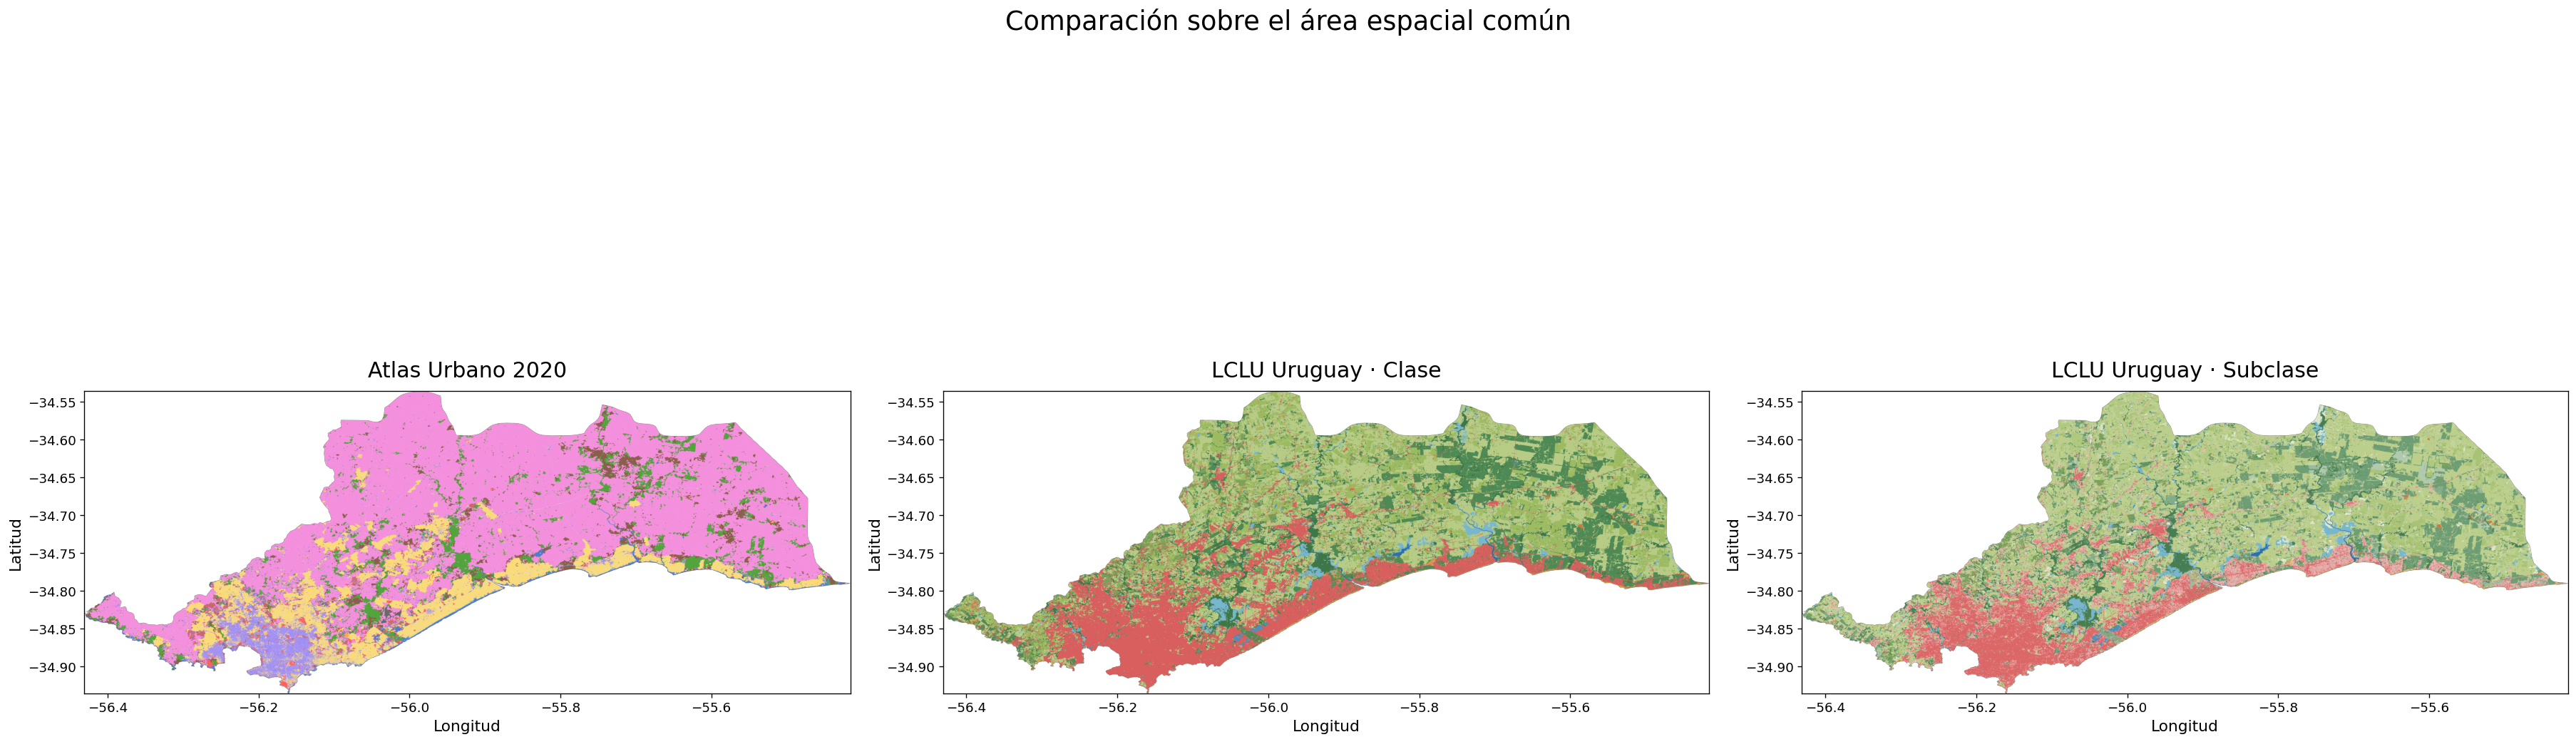

In [14]:
def mostrar_mapas_comparativos_globales():
    fig, axes = plt.subplots(
        1, 3,
        figsize=(30, 12),
        dpi=120,
        constrained_layout=True,
    )

    axes[0].imshow(
        rgba_au(au_comun, mascara_comun),
        extent=extent_comun,
        origin="upper",
    )
    axes[0].set_title("Atlas Urbano 2020", fontsize=18, pad=12)

    axes[1].imshow(
        rgba_desde_lookup(
            clase_comun,
            mascara_comun,
            lookup_clase,
            "ID_CLASE",
            "CLASE",
            COLORES_CLASE_LCLU,
        ),
        extent=extent_comun,
        origin="upper",
    )
    axes[1].set_title("LCLU Uruguay · Clase", fontsize=18, pad=12)

    axes[2].imshow(
        rgba_desde_lookup(
            subclase_comun,
            mascara_comun,
            lookup_subclase,
            "ID_SUBCLASE",
            "SUBCLASE",
            COLORES_SUBCLASE_LCLU,
        ),
        extent=extent_comun,
        origin="upper",
    )
    axes[2].set_title("LCLU Uruguay · Subclase", fontsize=18, pad=12)

    for ax in axes:
        ax.set_xlabel("Longitud", fontsize=13)
        ax.set_ylabel("Latitud", fontsize=13)
        ax.tick_params(labelsize=11)
        ax.set_aspect("equal")

    fig.suptitle(
        "Comparación sobre el área espacial común",
        fontsize=22,
        y=1.02,
    )
    plt.show()


mostrar_mapas_comparativos_globales()

## 7. Distribución de superficies

Las superficies se expresan en:

- **hectáreas (ha)**;
- **porcentaje (%)** del área común válida.

Para evitar distorsiones de área, el recorte común de los tres raster se reproyecta internamente a **EPSG:32721 (UTM 21S)** usando vecino más cercano.

In [15]:
src_bounds = array_bounds(
    au_comun.shape[0],
    au_comun.shape[1],
    tr_comun,
)

dst_transform, dst_width, dst_height = calculate_default_transform(
    SRC_CRS,
    CRS_AREA,
    au_comun.shape[1],
    au_comun.shape[0],
    *src_bounds,
)

au_utm = np.full((dst_height, dst_width), -9999, dtype=np.int32)
clase_utm = np.zeros((dst_height, dst_width), dtype=np.uint16)
subclase_utm = np.zeros((dst_height, dst_width), dtype=np.uint16)

reproject(
    source=au_comun.astype(np.int32),
    destination=au_utm,
    src_transform=tr_comun,
    src_crs=SRC_CRS,
    src_nodata=AU_NODATA,
    dst_transform=dst_transform,
    dst_crs=CRS_AREA,
    dst_nodata=-9999,
    resampling=Resampling.nearest,
)

reproject(
    source=clase_comun,
    destination=clase_utm,
    src_transform=tr_comun,
    src_crs=SRC_CRS,
    src_nodata=0,
    dst_transform=dst_transform,
    dst_crs=CRS_AREA,
    dst_nodata=0,
    resampling=Resampling.nearest,
)

reproject(
    source=subclase_comun,
    destination=subclase_utm,
    src_transform=tr_comun,
    src_crs=SRC_CRS,
    src_nodata=0,
    dst_transform=dst_transform,
    dst_crs=CRS_AREA,
    dst_nodata=0,
    resampling=Resampling.nearest,
)

mascara_comun_utm = (
    np.isin(au_utm, list(codigos_au_validos))
    & (clase_utm > 0)
)

area_pixel_ha = abs(dst_transform.a * dst_transform.e) / 10_000
area_comun_ha = mascara_comun_utm.sum() * area_pixel_ha

print(f"Área común válida aproximada: {area_comun_ha:,.1f} ha")
print(f"Área por píxel en la grilla métrica: {area_pixel_ha:.6f} ha")


def distribucion_categorica(arr, mascara, lookup, id_col, nombre_col):
    vals = arr[mascara].astype(int)
    ids, counts = np.unique(vals, return_counts=True)

    df = pd.DataFrame({
        id_col: ids,
        "n_pixeles": counts,
    })

    df["ha"] = df["n_pixeles"] * area_pixel_ha
    df = df.merge(lookup[[id_col, nombre_col]], on=id_col, how="left")
    df["porcentaje"] = 100 * df["ha"] / df["ha"].sum()

    return df.sort_values("ha", ascending=False).reset_index(drop=True)


vals_au = au_utm[mascara_comun_utm].astype(int)
ids_au, counts_au = np.unique(vals_au, return_counts=True)

dist_au = pd.DataFrame({
    "codigo": ids_au,
    "n_pixeles": counts_au,
})
dist_au["ha"] = dist_au["n_pixeles"] * area_pixel_ha
dist_au = dist_au.merge(
    leyenda_au[["codigo", "clase_au"]],
    on="codigo",
    how="left",
)
dist_au["porcentaje"] = 100 * dist_au["ha"] / dist_au["ha"].sum()

dist_lclu_clase = distribucion_categorica(
    clase_utm,
    mascara_comun_utm,
    lookup_clase,
    "ID_CLASE",
    "CLASE",
)

dist_lclu_subclase = distribucion_categorica(
    subclase_utm,
    mascara_comun_utm & (subclase_utm > 0),
    lookup_subclase,
    "ID_SUBCLASE",
    "SUBCLASE",
)

print("Atlas Urbano 2020")
display(dist_au[["codigo", "clase_au", "ha", "porcentaje"]].round({"ha": 1, "porcentaje": 2}))

print("LCLU Uruguay · Clase")
display(dist_lclu_clase[["ID_CLASE", "CLASE", "ha", "porcentaje"]].round({"ha": 1, "porcentaje": 2}))

print("LCLU Uruguay · Subclase")
display(dist_lclu_subclase[["ID_SUBCLASE", "SUBCLASE", "ha", "porcentaje"]].round({"ha": 1, "porcentaje": 2}))

Área común válida aproximada: 178,449.3 ha
Área por píxel en la grilla métrica: 0.006733 ha
Atlas Urbano 2020


,codigo,clase_au,ha,porcentaje
0,4368,4368 - Residencial,22565.8,12.65
1,4384,4384 - Comercial/Industrial,1785.6,1.00
2,4400,4400 - Edificios,8749.6,4.90
3,4624,4624 - Calles y ferrocarriles,4568.6,2.56
4,4640,4640 - Aeropuertos,237.1,0.13
5,5136,5136 - Vegetación boscosa,12859.3,7.21
6,5152,5152 - Agricultura,116147.5,65.09
7,5168,5168 - Recreación,2177.6,1.22
8,5184,5184 - Otros espacios abiertos,7178.5,4.02
9,36880,36880 - Extracción de minerales,84.7,0.05


LCLU Uruguay · Clase


,ID_CLASE,CLASE,ha,porcentaje
0,11,Pastizal,60700.7,34.02
1,5,Area Impermeable,37716.6,21.14
2,9,Cultivos,30209.4,16.93
3,12,Plantación Forestal,29727.0,16.66
4,7,Bosque Nativo,8394.5,4.70
5,6,Area Natural Inundada,4689.3,2.63
6,10,Frutales,3226.8,1.81
7,4,Area Desnuda,2105.0,1.18
8,1,Aguas Artificiales,670.5,0.38
9,2,Aguas Naturales,577.8,0.32


LCLU Uruguay · Subclase


,ID_SUBCLASE,SUBCLASE,ha,porcentaje
0,18,Pastizal,56926.1,31.90
1,2,Area Impermeable,23064.5,12.92
2,24,Plantación Forestal Eucaliptus,15775.6,8.84
3,3,Area Impermeable Dispersa,14652.0,8.21
4,12,Cultivo de invierno,9967.2,5.59
5,6,Bosque Nativo,8200.2,4.60
6,21,Pastizal de Uso Agrícola,6700.9,3.76
7,17,Monte de abrigo y sombra,6697.8,3.75
8,13,Cultivo de invierno y verano (Doble Cultivo),6307.4,3.53
9,25,Plantación Forestal Mixta o Desconocida,4941.9,2.77


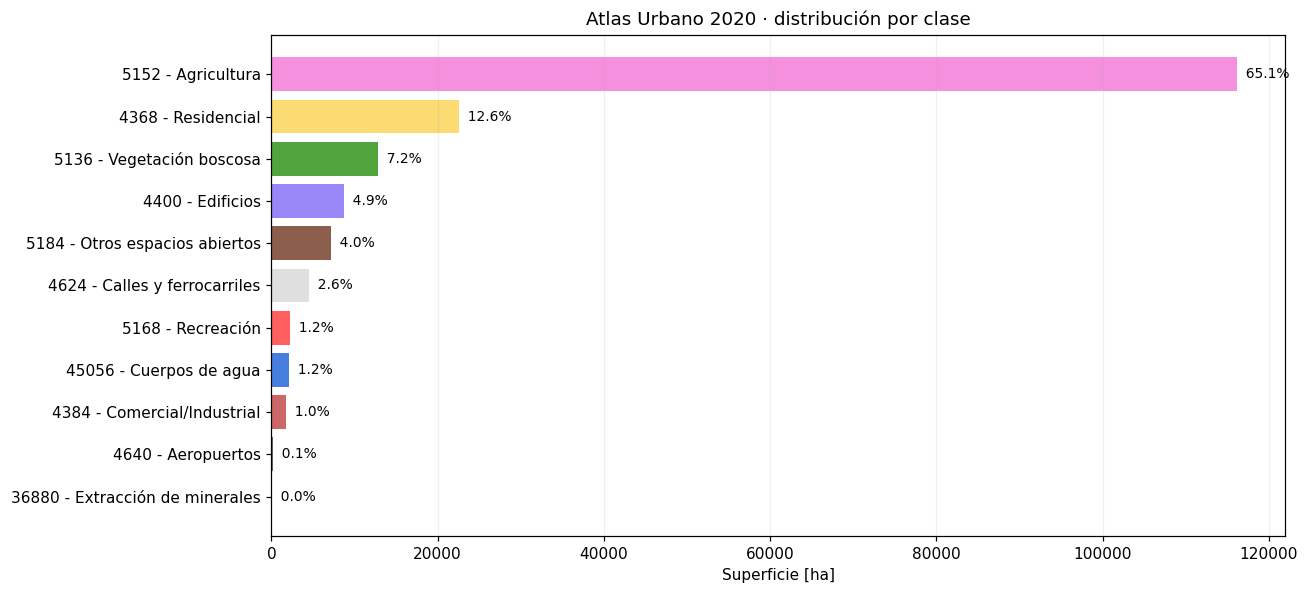

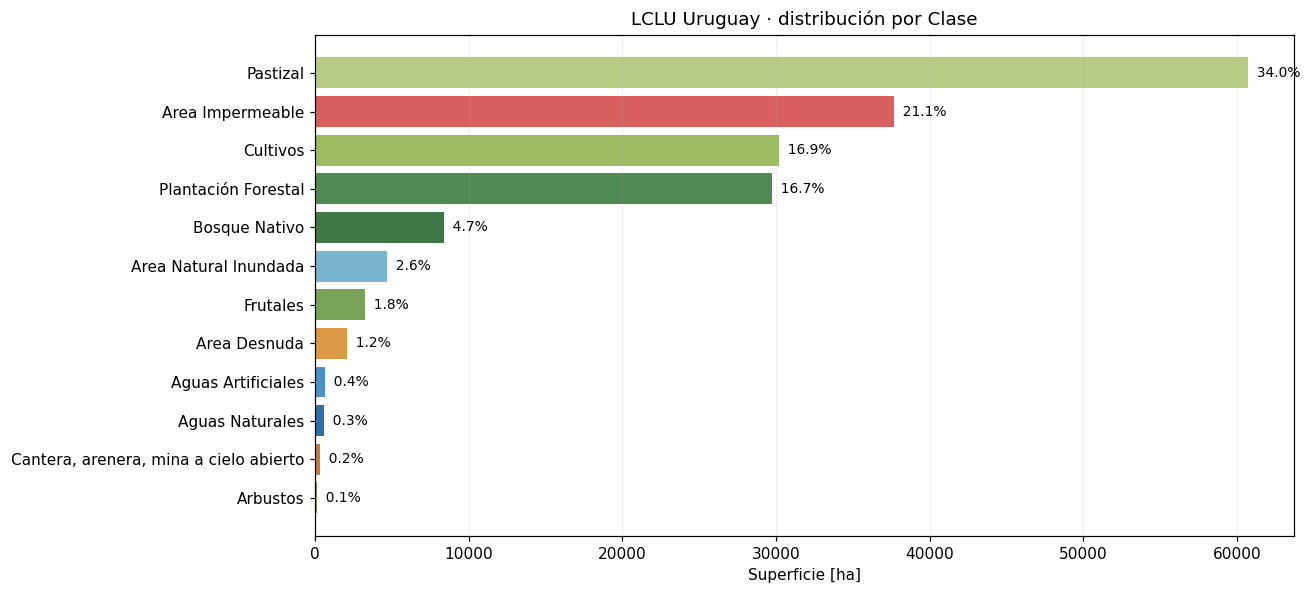

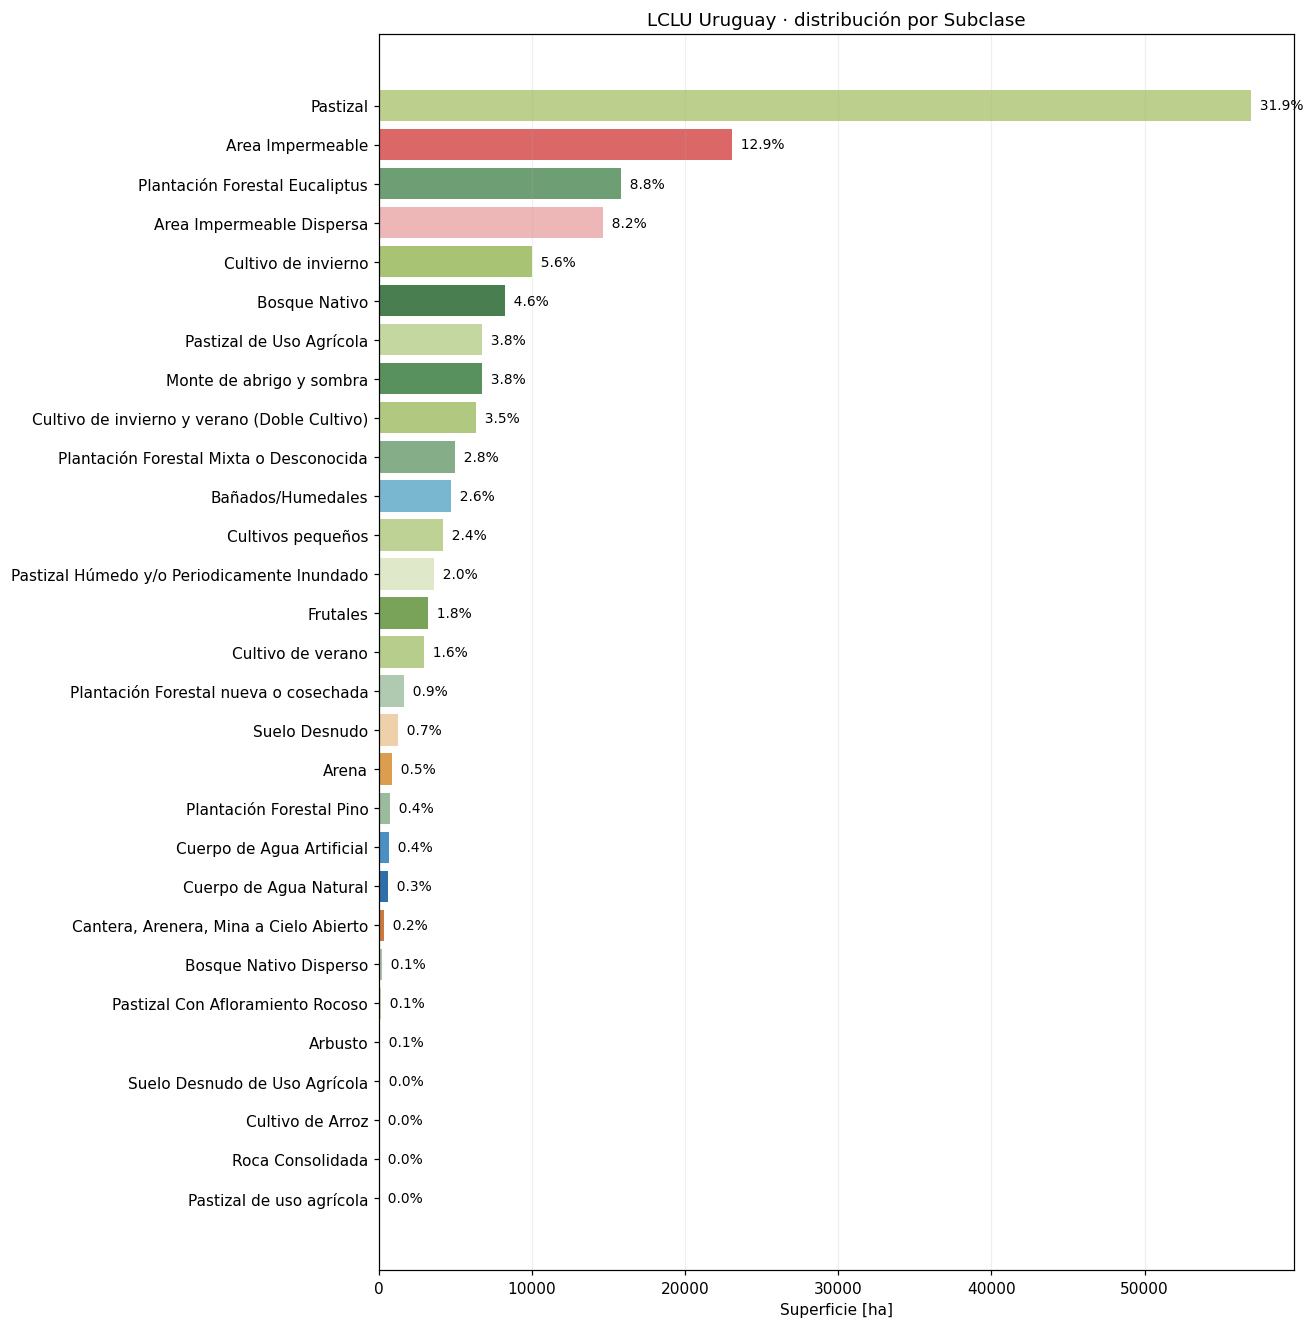

In [16]:
def grafico_distribucion(df, etiqueta, color_map, titulo):
    d = df.sort_values("ha", ascending=True).copy()
    colores = [color_map.get(v, "#888888") for v in d[etiqueta]]

    fig, ax = plt.subplots(figsize=(12, max(5.5, 0.42 * len(d))), dpi=110)
    bars = ax.barh(d[etiqueta], d["ha"], color=colores)

    ax.set_xlabel("Superficie [ha]")
    ax.set_title(titulo)
    ax.grid(axis="x", alpha=0.2)

    for bar, (_, r) in zip(bars, d.iterrows()):
        ax.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f"  {r['porcentaje']:.1f}%",
            va="center",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()


colores_au = dict(zip(leyenda_au["clase_au"], leyenda_au["color"]))

grafico_distribucion(
    dist_au.rename(columns={"clase_au": "Clase"}),
    "Clase",
    colores_au,
    "Atlas Urbano 2020 · distribución por clase",
)

grafico_distribucion(
    dist_lclu_clase,
    "CLASE",
    COLORES_CLASE_LCLU,
    "LCLU Uruguay · distribución por Clase",
)

grafico_distribucion(
    dist_lclu_subclase,
    "SUBCLASE",
    COLORES_SUBCLASE_LCLU,
    "LCLU Uruguay · distribución por Subclase",
)

## 8. Homologación temática AU ↔ LCLU Uruguay

Antes de superponer espacialmente los productos, se define una **homologación conceptual explícita y editable**. Esta tabla no supone equivalencia perfecta: registra relaciones directas, parciales y de tipo uno-a-varios.

La lógica general es:

**Atlas Urbano → nivel de agregación LAC → macroclase LCLU Uruguay → clase LCLU Uruguay**.

La comparación espacial posterior permitirá revisar cómo se manifiesta esa relación conceptual en el territorio.

In [17]:
# ============================================================
# TABLA DE HOMOLOGACIÓN EDITABLE
# ============================================================
# Los nombres LCLU utilizados aquí corresponden al campo CLASE del producto.
# La tabla puede modificarse si el equipo del taller decide ajustar alguna relación.

homologacion = pd.DataFrame([
    ["Residencial", "Área construida", "SUPERFICIES ARTIFICIALES Y AREAS SIMILARES", "Area Impermeable", "Alta", "El AU distingue uso/función urbana; LCLU representa principalmente cobertura impermeable."],
    ["Industrial", "Área construida", "SUPERFICIES ARTIFICIALES Y AREAS SIMILARES", "Area Impermeable", "Alta", "La cobertura impermeable puede reunir diferentes usos urbanos."],
    ["Edificios", "Área construida", "SUPERFICIES ARTIFICIALES Y AREAS SIMILARES", "Area Impermeable", "Alta", "Correspondencia principalmente por superficie artificial."],
    ["Calles y ferrocarriles", "Unidades de transporte", "SUPERFICIES ARTIFICIALES Y AREAS SIMILARES", "Area Impermeable", "Parcial", "LCLU no necesariamente separa la función de transporte de otras superficies impermeables."],
    ["Aeropuertos", "Unidades de transporte", "SUPERFICIES ARTIFICIALES Y AREAS SIMILARES", "Area Impermeable", "Parcial", "La infraestructura aeroportuaria puede repartirse entre superficies impermeables y coberturas abiertas."],
    ["Recreación", "Espacios abiertos", "VEGETACION NATURAL Y SEMI-NATURAL", "Pastizal; Arbustos; Bosque Nativo", "Uno-a-varios", "Una clase funcional del AU puede contener diferentes coberturas biofísicas."],
    ["Vegetación Arbolada", "Espacios abiertos", "VEGETACION NATURAL Y SEMI-NATURAL / AREAS TERRESTRES CULTIVADAS", "Bosque Nativo; Plantacion Forestal; Frutales", "Uno-a-varios", "El LCLU distingue origen y manejo de coberturas arboladas."],
    ["Agricultura", "Espacios abiertos", "AREAS TERRESTRES CULTIVADAS", "Cultivos; Frutales", "Uno-a-varios", "LCLU separa distintos tipos de coberturas agrícolas."],
    ["Otros espacios abiertos", "Espacios abiertos", "VEGETACION NATURAL Y SEMI-NATURAL / AREAS DESCUBIERTAS O DESNUDAS", "Pastizal; Arbustos; Area Desnuda", "Uno-a-varios", "Categoría AU amplia que puede contener varias coberturas LCLU."],
    ["Sitios de extracción de minerales", "Suelo desnudo", "SUPERFICIES ARTIFICIALES Y AREAS SIMILARES / AREAS DESCUBIERTAS O DESNUDAS", "Cantera, arenera, mina a cielo abierto; Area Desnuda", "Uno-a-varios", "La actividad extractiva puede aparecer como clase específica o como superficie desnuda."],
    ["Cuerpos de agua", "Cuerpos de Agua", "CUERPOS NATURALES / ARTIFICIALES DE AGUA Y VEGETACION REGULARMENTE INUNDADA", "Aguas Naturales; Aguas Artificiales; Area Natural Inundada", "Uno-a-varios", "LCLU distingue origen del cuerpo de agua y áreas inundadas."],
], columns=[
    "Clase_AU", "Nivel_agregacion_LAC", "Macroclase_LCLU", "Clase_LCLU_esperada", "Tipo_correspondencia", "Interpretacion"
])

homologacion

,Clase_AU,Nivel_agregacion_LAC,Macroclase_LCLU,Clase_LCLU_esperada,Tipo_correspondencia,Interpretacion
0,Residencial,Área construida,SUPERFICIES ARTIFICIALES Y AREAS SIMILARES,Area Impermeable,Alta,El AU distingue uso/función urbana; LCLU representa principalmente cobertura impermeable.
1,Industrial,Área construida,SUPERFICIES ARTIFICIALES Y AREAS SIMILARES,Area Impermeable,Alta,La cobertura impermeable puede reunir diferentes usos urbanos.
2,Edificios,Área construida,SUPERFICIES ARTIFICIALES Y AREAS SIMILARES,Area Impermeable,Alta,Correspondencia principalmente por superficie artificial.
3,Calles y ferrocarriles,Unidades de transporte,SUPERFICIES ARTIFICIALES Y AREAS SIMILARES,Area Impermeable,Parcial,LCLU no necesariamente separa la función de transporte de otras superficies impermeables.
4,Aeropuertos,Unidades de transporte,SUPERFICIES ARTIFICIALES Y AREAS SIMILARES,Area Impermeable,Parcial,La infraestructura aeroportuaria puede repartirse entre superficies impermeables y coberturas abiertas.
5,Recreación,Espacios abiertos,VEGETACION NATURAL Y SEMI-NATURAL,Pastizal; Arbustos; Bosque Nativo,Uno-a-varios,Una clase funcional del AU puede contener diferentes coberturas biofísicas.
6,Vegetación Arbolada,Espacios abiertos,VEGETACION NATURAL Y SEMI-NATURAL / AREAS TERRESTRES CULTIVADAS,Bosque Nativo; Plantacion Forestal; Frutales,Uno-a-varios,El LCLU distingue origen y manejo de coberturas arboladas.
7,Agricultura,Espacios abiertos,AREAS TERRESTRES CULTIVADAS,Cultivos; Frutales,Uno-a-varios,LCLU separa distintos tipos de coberturas agrícolas.
8,Otros espacios abiertos,Espacios abiertos,VEGETACION NATURAL Y SEMI-NATURAL / AREAS DESCUBIERTAS O DESNUDAS,Pastizal; Arbustos; Area Desnuda,Uno-a-varios,Categoría AU amplia que puede contener varias coberturas LCLU.
9,Sitios de extracción de minerales,Suelo desnudo,SUPERFICIES ARTIFICIALES Y AREAS SIMILARES / AREAS DESCUBIERTAS O DESNUDAS,"Cantera, arenera, mina a cielo abierto; Area Desnuda",Uno-a-varios,La actividad extractiva puede aparecer como clase específica o como superficie desnuda.


## 9. Matriz de correspondencia temática espacial

Ahora se mide la superposición efectiva entre las categorías.

Para cada clase del Atlas Urbano se calcula:

$$
P_{ij}
=
\frac{
A\left(AU_i \cap LCLU_j\right)
}{
A\left(AU_i\right)
}
\times 100
$$

donde:

- $AU_i$ corresponde a una clase del Atlas Urbano;
- $LCLU_j$ corresponde a una clase del LCLU Uruguay;
- $A(AU_i \cap LCLU_j)$ es el área donde ambas clases coinciden espacialmente;
- $A(AU_i)$ es el área total de la clase del Atlas Urbano dentro del área de comparación;
- $P_{ij}$ es el porcentaje de la clase $AU_i$ que coincide con la clase $LCLU_j$.

### ¿Cómo se interpreta la matriz?

- Cada **fila** corresponde a una clase del Atlas Urbano.
- Cada **columna** corresponde a una clase del LCLU Uruguay.
- Cada **celda** indica el porcentaje de superficie compartida entre ambas categorías.
- En condiciones ideales, los porcentajes de cada fila suman aproximadamente **100 %**.

> **Importante:** esta matriz no representa una medida de exactitud ni una matriz de confusión, porque ninguno de los dos productos se considera verdad terreno. Su objetivo es identificar **correspondencias, fragmentaciones y diferencias temáticas** entre ambos sistemas de clasificación.

In [18]:
def matriz_correspondencia_desde_mascara(mascara):
    valido = (
        mascara
        & np.isin(au_utm, list(codigos_au_validos))
        & (clase_utm > 0)
    )

    df = pd.DataFrame({
        "codigo_au": au_utm[valido].astype(int),
        "ID_CLASE": clase_utm[valido].astype(int),
    })

    tabla = pd.crosstab(df["codigo_au"], df["ID_CLASE"])

    mapa_au = dict(zip(leyenda_au["codigo"], leyenda_au["clase_au"]))
    mapa_lclu = dict(zip(lookup_clase["ID_CLASE"], lookup_clase["CLASE"]))

    tabla.index = tabla.index.map(mapa_au)
    tabla.columns = tabla.columns.map(mapa_lclu)

    pct = tabla.div(tabla.sum(axis=1), axis=0) * 100

    return tabla, pct


matriz_npix, matriz_pct = matriz_correspondencia_desde_mascara(mascara_comun_utm)

display(matriz_pct.round(1))

ID_CLASE,Aguas Artificiales,Aguas Naturales,Arbustos,Area Desnuda,Area Impermeable,Area Natural Inundada,Bosque Nativo,"Cantera, arenera, mina a cielo abierto",Cultivos,Frutales,Pastizal,Plantación Forestal
codigo_au,,,,,,,,,,,,
4368 - Residencial,0.3,0.1,0.0,1.4,78.9,0.7,2.1,0.1,2.3,0.3,7.2,6.6
4384 - Comercial/Industrial,2.9,0.7,0.0,5.3,63.2,1.5,2.2,2.3,3.6,0.2,12.9,5.3
4400 - Edificios,0.1,0.1,0.0,0.8,92.6,0.2,0.4,0.1,1.1,0.2,2.7,1.9
4624 - Calles y ferrocarriles,0.0,0.0,0.0,0.6,95.9,0.1,0.1,0.0,0.4,0.1,1.4,1.4
4640 - Aeropuertos,0.0,0.1,0.0,5.0,31.5,0.4,0.4,0.0,1.9,0.1,59.5,1.0
5136 - Vegetación boscosa,0.2,0.9,0.0,1.0,1.9,6.0,27.7,0.1,1.5,0.4,9.2,51.0
5152 - Agricultura,0.3,0.1,0.1,0.5,3.7,2.4,2.8,0.1,24.9,2.6,47.0,15.5
5168 - Recreación,1.7,0.8,0.0,4.1,36.7,2.1,3.7,0.3,6.0,0.3,32.1,12.3
5184 - Otros espacios abiertos,0.2,1.0,0.1,3.2,2.9,11.7,12.4,1.3,3.3,0.3,24.9,38.7


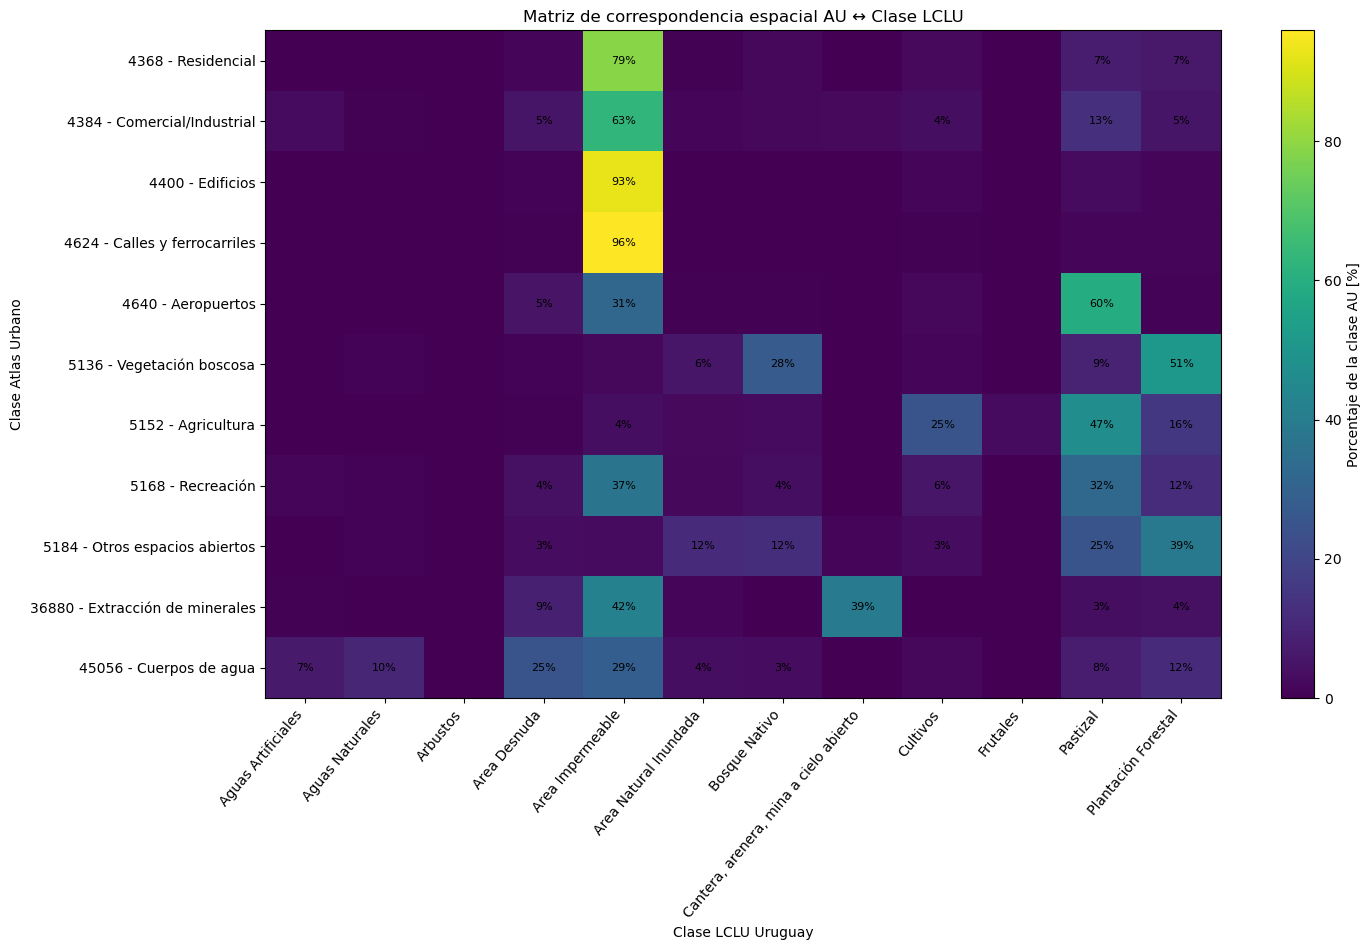

In [19]:
def plot_heatmap_correspondencia(matriz, titulo="Matriz de correspondencia espacial AU ↔ Clase LCLU"):
    M = matriz.copy()
    fig_w = max(11, 0.9 * M.shape[1] + 4)
    fig_h = max(6, 0.6 * M.shape[0] + 3)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    im = ax.imshow(M.values, aspect="auto", vmin=0, vmax=max(50, np.nanmax(M.values)))
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Porcentaje de la clase AU [%]")

    ax.set_xticks(np.arange(M.shape[1]))
    ax.set_xticklabels(M.columns, rotation=50, ha="right")
    ax.set_yticks(np.arange(M.shape[0]))
    ax.set_yticklabels(M.index)
    ax.set_xlabel("Clase LCLU Uruguay")
    ax.set_ylabel("Clase Atlas Urbano")
    ax.set_title(titulo)

    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            val = M.iloc[i, j]
            if np.isfinite(val) and val >= 3:
                ax.text(j, i, f"{val:.0f}%", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

plot_heatmap_correspondencia(matriz_pct)

## 10. Principales correspondencias observadas

Para facilitar la lectura, resumimos para cada clase AU sus dos clases LCLU con mayor superposición. Esto permite detectar rápidamente:

- correspondencias concentradas en una sola clase;
- clases AU que se fragmentan entre varias clases LCLU;
- diferencias que pueden estar asociadas a la taxonomía y no necesariamente a cambios reales del territorio.

In [20]:
def principales_correspondencias(matriz_pct, n=2):
    filas = []
    for clase_au, row in matriz_pct.iterrows():
        orden = row.sort_values(ascending=False)
        reg = {"Clase_AU": clase_au}
        for k in range(n):
            if k < len(orden):
                reg[f"Correspondencia_{k+1}"] = orden.index[k]
                reg[f"Porcentaje_{k+1}"] = orden.iloc[k]
        filas.append(reg)
    return pd.DataFrame(filas)

principales = principales_correspondencias(matriz_pct, n=2)
principales.round(1)

,Clase_AU,Correspondencia_1,Porcentaje_1,Correspondencia_2,Porcentaje_2
0,4368 - Residencial,Area Impermeable,78.9,Pastizal,7.2
1,4384 - Comercial/Industrial,Area Impermeable,63.2,Pastizal,12.9
2,4400 - Edificios,Area Impermeable,92.6,Pastizal,2.7
3,4624 - Calles y ferrocarriles,Area Impermeable,95.9,Pastizal,1.4
4,4640 - Aeropuertos,Pastizal,59.5,Area Impermeable,31.5
5,5136 - Vegetación boscosa,Plantación Forestal,51.0,Bosque Nativo,27.7
6,5152 - Agricultura,Pastizal,47.0,Cultivos,24.9
7,5168 - Recreación,Area Impermeable,36.7,Pastizal,32.1
8,5184 - Otros espacios abiertos,Plantación Forestal,38.7,Pastizal,24.9
9,36880 - Extracción de minerales,Area Impermeable,42.2,"Cantera, arenera, mina a cielo abierto",39.1


## 11. Resultados locales: selección interactiva por Departamento y Municipio

Hasta ahora trabajamos con toda el área común. En esta sección se repite una versión resumida del análisis para un territorio local.

Se utiliza un **widget interactivo**, siguiendo la misma lógica de los otros notebooks del taller:

1. seleccionar un **Departamento**;
2. seleccionar un **Municipio** o `TODO EL DEPARTAMENTO`;
3. presionar **Actualizar resultados**.

El widget actualizará mapas comparativos, distribución de superficies, matriz de correspondencia y principales correspondencias.

In [21]:
def detectar_campos_admin(gdf):
    dep = buscar_columna(
        gdf,
        ["depto", "departamento", "dpto", "nom_depto", "nombre_dep", "departamen"],
        requerida=False,
    )
    mun = buscar_columna(
        gdf,
        ["municipio", "muni", "nom_muni", "nombre_mun", "municip"],
        requerida=False,
    )
    return dep, mun


admin = gpd.read_file(MUNICIPIOS)
CAMPO_DEPTO, CAMPO_MUNI = detectar_campos_admin(admin)

if CAMPO_DEPTO is None or CAMPO_MUNI is None:
    raise ValueError(
        "No fue posible detectar los campos de Departamento y Municipio "
        "en municipios_20250507.shp."
    )

admin = admin[[CAMPO_DEPTO, CAMPO_MUNI, "geometry"]].copy()
admin[CAMPO_DEPTO] = admin[CAMPO_DEPTO].map(limpiar_etiqueta)
admin[CAMPO_MUNI] = admin[CAMPO_MUNI].map(limpiar_etiqueta)
admin = admin[admin.geometry.notna() & ~admin.geometry.is_empty].copy()

print("CRS límites administrativos:", admin.crs)
print("Departamentos disponibles:", admin[CAMPO_DEPTO].nunique())
print("Municipios disponibles:", admin[CAMPO_MUNI].nunique())

CRS límites administrativos: EPSG:4326
Departamentos disponibles: 19
Municipios disponibles: 133


In [22]:
def geometria_local(departamento, municipio="TODO EL DEPARTAMENTO"):
    sel = admin[admin[CAMPO_DEPTO] == departamento].copy()

    if sel.empty:
        raise ValueError(f"Departamento no encontrado: {departamento}")

    if municipio != "TODO EL DEPARTAMENTO":
        sel = sel[sel[CAMPO_MUNI] == municipio].copy()

        if sel.empty:
            raise ValueError(
                f"Municipio no encontrado en {departamento}: {municipio}"
            )

        etiqueta = f"{departamento} · {municipio}"

    else:
        etiqueta = f"{departamento} · Todo el departamento"

    geom = unary_union(sel.geometry.values)
    return geom, admin.crs, etiqueta


def mascara_local_utm(geom, geom_crs):
    geom_utm = gpd.GeoSeries([geom], crs=geom_crs).to_crs(CRS_AREA).iloc[0]

    m = rasterize(
        [(mapping(geom_utm), 1)],
        out_shape=au_utm.shape,
        transform=dst_transform,
        fill=0,
        dtype="uint8",
        all_touched=False,
    ).astype(bool)

    return m & mascara_comun_utm


def leer_tres_raster_locales(geom, geom_crs):
    geom_src = gpd.GeoSeries([geom], crs=geom_crs).to_crs(SRC_CRS).iloc[0]
    shapes = [mapping(geom_src)]

    with rasterio.open(RASTER_AU_2020) as a, \
         rasterio.open(LCLU_CLASE) as c, \
         rasterio.open(LCLU_SUBCLASE) as s:

        au, tr = mask(a, shapes, crop=True, filled=True, nodata=a.nodata)
        lc, _ = mask(c, shapes, crop=True, filled=True, nodata=0)
        ls, _ = mask(s, shapes, crop=True, filled=True, nodata=0)

    au = au[0]
    lc = lc[0]
    ls = ls[0]

    mascara = np.isin(au.astype(np.int64), list(codigos_au_validos)) & (lc > 0)

    b = array_bounds(au.shape[0], au.shape[1], tr)
    extent = [b[0], b[2], b[1], b[3]]

    return au, lc, ls, mascara, extent


def mostrar_mapas_locales(geom, geom_crs, titulo):
    au, lc, ls, mascara, extent = leer_tres_raster_locales(geom, geom_crs)

    fig, axes = plt.subplots(
        1, 3,
        figsize=(28, 11),
        dpi=115,
        constrained_layout=True,
    )

    axes[0].imshow(rgba_au(au, mascara), extent=extent, origin="upper")
    axes[0].set_title("Atlas Urbano 2020", fontsize=17)

    axes[1].imshow(
        rgba_desde_lookup(
            lc, mascara, lookup_clase,
            "ID_CLASE", "CLASE", COLORES_CLASE_LCLU,
        ),
        extent=extent,
        origin="upper",
    )
    axes[1].set_title("LCLU Uruguay · Clase", fontsize=17)

    axes[2].imshow(
        rgba_desde_lookup(
            ls, mascara, lookup_subclase,
            "ID_SUBCLASE", "SUBCLASE", COLORES_SUBCLASE_LCLU,
        ),
        extent=extent,
        origin="upper",
    )
    axes[2].set_title("LCLU Uruguay · Subclase", fontsize=17)

    for ax in axes:
        ax.set_xlabel("Longitud")
        ax.set_ylabel("Latitud")
        ax.set_aspect("equal")

    fig.suptitle(titulo, fontsize=21, y=1.02)
    plt.show()

In [23]:
# ============================================================
# WIDGET DE SELECCIÓN TERRITORIAL
# ============================================================

departamentos = sorted(admin[CAMPO_DEPTO].dropna().unique())

widget_departamento = widgets.Dropdown(
    options=departamentos,
    value=departamentos[0],
    description="Departamento:",
    style={"description_width": "110px"},
    layout=widgets.Layout(width="420px"),
)

widget_municipio = widgets.Dropdown(
    description="Municipio:",
    style={"description_width": "110px"},
    layout=widgets.Layout(width="420px"),
)

boton_actualizar = widgets.Button(
    description="Actualizar resultados",
    button_style="primary",
    icon="refresh",
    layout=widgets.Layout(width="220px"),
)

salida_local = widgets.Output()


def actualizar_municipios(*args):
    departamento = widget_departamento.value

    municipios = sorted(
        admin.loc[
            admin[CAMPO_DEPTO] == departamento,
            CAMPO_MUNI,
        ]
        .dropna()
        .unique()
    )

    widget_municipio.options = [
        "TODO EL DEPARTAMENTO",
        *municipios,
    ]
    widget_municipio.value = "TODO EL DEPARTAMENTO"


widget_departamento.observe(
    actualizar_municipios,
    names="value",
)

actualizar_municipios()

display(
    widgets.VBox([
        widgets.HTML("<b>Seleccione el área de estudio</b>"),
        widget_departamento,
        widget_municipio,
        boton_actualizar,
    ]),
    salida_local,
)

Output()

In [25]:
def ejecutar_resultados_locales(_=None):
    with salida_local:
        clear_output(wait=True)

        departamento = widget_departamento.value
        municipio = widget_municipio.value

        geom, geom_crs, etiqueta = geometria_local(
            departamento,
            municipio,
        )

        mascara_local = mascara_local_utm(
            geom,
            geom_crs,
        )

        if not mascara_local.any():
            print(
                "La unidad seleccionada no presenta píxeles comunes "
                "entre AU y LCLU."
            )
            return

        print(f"Territorio seleccionado: {etiqueta}")
        print(
            f"Área común válida local: "
            f"{mascara_local.sum() * area_pixel_ha:,.1f} ha"
        )

        mostrar_mapas_locales(
            geom,
            geom_crs,
            f"Resultados locales · {etiqueta}",
        )

        local_au_vals = au_utm[mascara_local].astype(int)
        ids, counts = np.unique(local_au_vals, return_counts=True)

        local_au = pd.DataFrame({
            "codigo": ids,
            "n_pixeles": counts,
        })
        local_au["ha"] = local_au["n_pixeles"] * area_pixel_ha
        local_au = local_au.merge(
            leyenda_au[["codigo", "clase_au"]],
            on="codigo",
            how="left",
        )
        local_au["porcentaje"] = (
            100 * local_au["ha"] / local_au["ha"].sum()
        )

        local_lclu = distribucion_categorica(
            clase_utm,
            mascara_local,
            lookup_clase,
            "ID_CLASE",
            "CLASE",
        )

        print("\nAtlas Urbano 2020 · distribución local")
        display(
            local_au[
                ["codigo", "clase_au", "ha", "porcentaje"]
            ].round({"ha": 1, "porcentaje": 2})
        )

        print("\nLCLU Uruguay · Clase · distribución local")
        display(
            local_lclu[
                ["ID_CLASE", "CLASE", "ha", "porcentaje"]
            ].round({"ha": 1, "porcentaje": 2})
        )

        _, matriz_pct_local = matriz_correspondencia_desde_mascara(
            mascara_local
        )

        plot_heatmap_correspondencia(
            matriz_pct_local,
            titulo=f"Correspondencia AU ↔ Clase LCLU · {etiqueta}",
        )

        print("\nPrincipales correspondencias:")
        display(
            principales_correspondencias(
                matriz_pct_local,
                n=2,
            ).round(1)
        )


boton_actualizar.on_click(ejecutar_resultados_locales)

print(
    "Widget listo. Seleccione Departamento y Municipio y presione "
    "'Actualizar resultados'."
)

Widget listo. Seleccione Departamento y Municipio y presione 'Actualizar resultados'.


### Cómo usar esta sección

El análisis local ya no requiere editar variables manualmente. Utilice los controles del widget anterior y presione **Actualizar resultados** cada vez que quiera analizar una nueva unidad territorial.

## 12. Preguntas para interpretar los resultados

Antes de avanzar al análisis temporal AU 2020–2024, discuta:

1. **¿Qué clases presentan una correspondencia espacial clara entre ambos productos?**
2. **¿Qué clases AU se distribuyen entre varias clases LCLU Uruguay?**
3. **¿Las diferencias observadas pueden explicarse por el distinto nivel de detalle de las leyendas?**
4. **¿Qué papel pueden tener el formato, la resolución espacial, la unidad mínima de mapeo y la metodología de clasificación?**
5. **¿Por qué no sería correcto interpretar automáticamente una diferencia AU 2020 vs. LCLU 2021 como cambio de cobertura?**
6. **¿La relación entre productos cambia al pasar del área completa a un departamento o municipio específico?**


## 13. Exportación de resultados

La siguiente celda guarda los resultados correspondientes al Departamento o Municipio actualmente seleccionado en el widget de la sección anterior.

Los resultados se almacenan en:

`outputs/output_AU/0_Comparacion_productos/`

In [32]:
# ============================================================
# GUARDAR RESULTADOS DEL ÁREA SELECCIONADA
# ============================================================

if GUARDAR_SALIDAS:
    departamento = widget_departamento.value
    municipio = widget_municipio.value

    geom, geom_crs, etiqueta = geometria_local(
        departamento,
        municipio,)

    mascara_local = mascara_local_utm(
        geom,
        geom_crs,)

    if not mascara_local.any():
        print("La unidad seleccionada no presenta píxeles comunes "
            "entre AU y LCLU.")
    else:
        # ========================================================
        # CARPETA DE SALIDA
        # ========================================================
        nombre_area = (
            etiqueta
            .replace(" · ", "_")
            .replace(" ", "_"))
        carpeta_salida = OUTPUT_DIR / nombre_area
        carpeta_salida.mkdir(parents=True, exist_ok=True)
        # ========================================================
        # DISTRIBUCIONES LOCALES
        # ========================================================
        # Atlas Urbano
        local_au_vals = au_utm[mascara_local].astype(int)
        ids, counts = np.unique(local_au_vals, return_counts=True)

        local_au = pd.DataFrame({
            "codigo": ids,
            "n_pixeles": counts,})
        local_au["ha"] = local_au["n_pixeles"] * area_pixel_ha
        local_au = local_au.merge(
            leyenda_au[["codigo", "clase_au"]],
            on="codigo",
            how="left",)
        local_au["porcentaje"] = (
            100 * local_au["ha"] / local_au["ha"].sum())

        # LCLU Clase
        local_lclu = distribucion_categorica(
            clase_utm,
            mascara_local,
            lookup_clase,
            "ID_CLASE",
            "CLASE",)

        # LCLU Subclase
        local_lclu_subclase = distribucion_categorica(
            subclase_utm,
            mascara_local & (subclase_utm > 0),
            lookup_subclase,
            "ID_SUBCLASE",
            "SUBCLASE",)
        # ========================================================
        # MATRIZ DE CORRESPONDENCIA
        # ========================================================
        _, matriz_pct_local = matriz_correspondencia_desde_mascara(
            mascara_local)
        correspondencias_locales = principales_correspondencias(
            matriz_pct_local,
            n=2,)
        # ========================================================
        # GUARDAR TABLAS
        # ========================================================
        local_au.to_csv(
            carpeta_salida / "distribucion_atlas_urbano.csv",
            index=False,)
        local_lclu.to_csv(
            carpeta_salida / "distribucion_lclu_clase.csv",
            index=False,)

        local_lclu_subclase.to_csv(
            carpeta_salida / "distribucion_lclu_subclase.csv",
            index=False,)
        matriz_pct_local.to_csv(
            carpeta_salida / "matriz_correspondencia_AU_LCLU.csv",)
        correspondencias_locales.to_csv(
            carpeta_salida / "principales_correspondencias.csv",
            index=False,)
        # ========================================================
        # GUARDAR ÁREA SELECCIONADA
        # ========================================================
        area_seleccionada = gpd.GeoDataFrame(
            {
                "departamento": [departamento],
                "municipio": [municipio],
                "area_comun_ha": [
                    mascara_local.sum() * area_pixel_ha
                ],
            },
            geometry=[geom],
            crs=geom_crs,)
        area_seleccionada.to_file(
            carpeta_salida / "area_seleccionada.geojson",
            driver="GeoJSON",)
        # ========================================================
        # 1. MAPAS COMPARATIVOS LOCALES
        # ========================================================
        au_loc, lc_loc, ls_loc, mascara_loc, extent_loc = (
            leer_tres_raster_locales(
                geom,
                geom_crs,
            )
        )

        fig, axes = plt.subplots(
            1,
            3,
            figsize=(28, 11),
            dpi=150,
            constrained_layout=True,)
        axes[0].imshow(
            rgba_au(
                au_loc,
                mascara_loc,
            ),
            extent=extent_loc,
            origin="upper",)
        axes[0].set_title(
            "Atlas Urbano 2020",
            fontsize=17,)

        axes[1].imshow(
            rgba_desde_lookup(
                lc_loc,
                mascara_loc,
                lookup_clase,
                "ID_CLASE",
                "CLASE",
                COLORES_CLASE_LCLU,
            ),
            extent=extent_loc,
            origin="upper",)

        axes[1].set_title(
            "LCLU Uruguay · Clase",
            fontsize=17,)

        axes[2].imshow(
            rgba_desde_lookup(
                ls_loc,
                mascara_loc,
                lookup_subclase,
                "ID_SUBCLASE",
                "SUBCLASE",
                COLORES_SUBCLASE_LCLU,
            ),
            extent=extent_loc,
            origin="upper",)

        axes[2].set_title(
            "LCLU Uruguay · Subclase",
            fontsize=17,)

        for ax in axes:
            ax.set_xlabel("Longitud")
            ax.set_ylabel("Latitud")
            ax.set_aspect("equal")

        fig.suptitle(
            f"Resultados locales · {etiqueta}",
            fontsize=21,
            y=1.02,)

        fig.savefig(
            carpeta_salida / "mapas_comparativos_locales.png",
            dpi=300,
            bbox_inches="tight",)
        plt.close(fig)
        # ========================================================
        # 2. DISTRIBUCIÓN ATLAS URBANO
        # ========================================================
        d = local_au.sort_values(
            "ha",
            ascending=True,
        ).copy()
        colores = [
            colores_au.get(
                v,
                "#888888",
            )
            for v in d["clase_au"]
        ]

        fig, ax = plt.subplots(
            figsize=(12, max(5.5, 0.42 * len(d))),
            dpi=110,)

        bars = ax.barh(
            d["clase_au"],
            d["ha"],
            color=colores,)

        ax.set_xlabel("Superficie [ha]")

        ax.set_title(
            f"Atlas Urbano 2020 · distribución local · {etiqueta}")
        ax.grid(
            axis="x",
            alpha=0.2,)

        for bar, (_, r) in zip(
            bars,
            d.iterrows(),
        ):
            ax.text(
                bar.get_width(),
                bar.get_y() + bar.get_height() / 2,
                f"  {r['porcentaje']:.1f}%",
                va="center",
                fontsize=9,)

        plt.tight_layout()
        fig.savefig(
            carpeta_salida / "distribucion_atlas_urbano.png",
            dpi=300,
            bbox_inches="tight",)

        plt.close(fig)
        # ========================================================
        # 3. DISTRIBUCIÓN LCLU CLASE
        # ========================================================
        d = local_lclu.sort_values(
            "ha",
            ascending=True,
        ).copy()

        colores = [
            COLORES_CLASE_LCLU.get(
                v,
                "#888888",
            )
            for v in d["CLASE"]
        ]

        fig, ax = plt.subplots(
            figsize=(12, max(5.5, 0.42 * len(d))),
            dpi=110,)

        bars = ax.barh(
            d["CLASE"],
            d["ha"],
            color=colores,)

        ax.set_xlabel("Superficie [ha]")

        ax.set_title(
            f"LCLU Uruguay · distribución por Clase · {etiqueta}")

        ax.grid(
            axis="x",
            alpha=0.2,)

        for bar, (_, r) in zip(
            bars,
            d.iterrows(),
        ):
            ax.text(
                bar.get_width(),
                bar.get_y() + bar.get_height() / 2,
                f"  {r['porcentaje']:.1f}%",
                va="center",
                fontsize=9,
            )

        plt.tight_layout()
        fig.savefig(
            carpeta_salida / "distribucion_lclu_clase.png",
            dpi=300,
            bbox_inches="tight",)
        plt.close(fig)
        # ========================================================
        # 4. DISTRIBUCIÓN LCLU SUBCLASE
        # ========================================================
        d = local_lclu_subclase.sort_values(
            "ha",
            ascending=True,
        ).copy()
        colores = [
            COLORES_SUBCLASE_LCLU.get(
                v,
                "#888888",
            )
            for v in d["SUBCLASE"]
        ]
        fig, ax = plt.subplots(
            figsize=(12, max(6, 0.42 * len(d))),
            dpi=110,)

        bars = ax.barh(
            d["SUBCLASE"],
            d["ha"],
            color=colores,)

        ax.set_xlabel("Superficie [ha]")
        ax.set_title(
            f"LCLU Uruguay · distribución por Subclase · {etiqueta}")
        ax.grid(
            axis="x",
            alpha=0.2,)

        for bar, (_, r) in zip(
            bars,
            d.iterrows(),
        ):
            ax.text(
                bar.get_width(),
                bar.get_y() + bar.get_height() / 2,
                f"  {r['porcentaje']:.1f}%",
                va="center",
                fontsize=9,)

        plt.tight_layout()
        fig.savefig(
            carpeta_salida / "distribucion_lclu_subclase.png",
            dpi=300,
            bbox_inches="tight",)
        plt.close(fig)
        # ========================================================
        # 5. MATRIZ DE CORRESPONDENCIA
        # ========================================================
        M = matriz_pct_local.copy()
        fig_w = max(
            11,
            0.9 * M.shape[1] + 4,)
        fig_h = max(
            6,
            0.6 * M.shape[0] + 3,)
        fig, ax = plt.subplots(
            figsize=(fig_w, fig_h))

        im = ax.imshow(
            M.values,
            aspect="auto",
            vmin=0,
            vmax=max(
                50,
                np.nanmax(M.values),
            ),
        )
        cbar = fig.colorbar(
            im,
            ax=ax,)

        cbar.set_label(
            "Porcentaje de la clase AU [%]")
        ax.set_xticks(
            np.arange(M.shape[1]))
        ax.set_xticklabels(
            M.columns,
            rotation=50,
            ha="right",)
        ax.set_yticks(
            np.arange(M.shape[0]))
        ax.set_yticklabels(
            M.index)

        ax.set_xlabel(
            "Clase LCLU Uruguay")

        ax.set_ylabel(
            "Clase Atlas Urbano")
        ax.set_title(
            f"Correspondencia AU ↔ Clase LCLU · {etiqueta}")
        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                val = M.iloc[i, j]
                if (
                    np.isfinite(val)
                    and val >= 3
                ):
                    ax.text(
                        j,
                        i,
                        f"{val:.0f}%",
                        ha="center",
                        va="center",
                        fontsize=8,)

        plt.tight_layout()
        fig.savefig(
            carpeta_salida / "matriz_correspondencia_AU_LCLU.png",
            dpi=300,
            bbox_inches="tight",)
        plt.close(fig)
        # ========================================================
        # RESUMEN
        # ========================================================
        print("Resultados guardados correctamente en:")
        print(carpeta_salida.resolve())
        print("\nArchivos generados:")
        for archivo in sorted(
            carpeta_salida.iterdir()
        ):
            print(" -", archivo.name)

Resultados guardados correctamente en:
C:\Users\fguti\OneDrive\Documentos\Taller-IDE-Uruguay\outputs\output_AU\0_Comparacion_productos\MONTEVIDEO_Todo_el_departamento

Archivos generados:
 - area_seleccionada.geojson
 - distribucion_atlas_urbano.csv
 - distribucion_atlas_urbano.png
 - distribucion_lclu.csv
 - distribucion_lclu_clase.csv
 - distribucion_lclu_clase.png
 - distribucion_lclu_subclase.csv
 - distribucion_lclu_subclase.png
 - mapas_comparativos_locales.png
 - matriz_correspondencia_AU_LCLU.csv
 - matriz_correspondencia_AU_LCLU.png
 - principales_correspondencias.csv



### Siguiente etapa del taller

Este notebook compara **productos diferentes**. Los notebooks siguientes trabajan con el mismo producto Atlas Urbano y estudian directamente las modificaciones entre **2020 y 2024**, primero mediante una versión guiada y posteriormente mediante una versión analítica más completa.